# Customer Profiling v2 — A Frequency-Severity Playbook

> **Methodology informed by Claude Opus-4.6 deep research.**
> This notebook extends the classical two-stage GLM (v1) with a GBM benchmark,
> Gini-based model comparison, loss-factor decile analysis, randomized quantile
> residuals, surrogate-tree segmentation, bootstrap uncertainty quantification,
> and a management-ready action matrix.
>
> *References: Ohlsson & Johansson (2010), Frees (2010), Goldburd et al. (2020,
> CAS Monograph 5), Henckaerts et al. (2021, NAAJ), Dunn & Smyth (1996),
> Garrido, Genest & Schulz (2016, IME), Werner & Modlin (2016).*

**Course:** Statistical Consulting (KU Leuven)

$$\hat{\pi}(\mathbf{x})
   = \underbrace{\hat{p}(\mathbf{x})}_{\text{frequency}}
   \;\times\;
   \underbrace{\hat{\mu}(\mathbf{x})}_{\text{severity}}$$

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gamma as gamma_dist, norm, spearmanr
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
)
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.metrics import roc_auc_score, brier_score_loss, mean_absolute_error

from src import (
    data_loader, preprocessing,
    frequency_model, severity_model,
    pure_premium, profiling, plots, style,
)
from src.config import FREQ_TARGET, SEV_TARGET

style.apply_warm_theme()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

---
## 1. Data & Methodology

Two non-linkable tables from the same car-insurance portfolio (2009–2010).
The marginal-product decomposition $\hat\pi(\mathbf x) = \hat P(\text{claim}|\mathbf x)\cdot\hat E[\text{cost}|\text{claim},\mathbf x]$
is the **only identifiable estimator** when record-level linkage is absent —
and it is the canonical approach prescribed by every major actuarial textbook.
Without linkage, dependent-frequency-severity models (copulas, Tweedie, Heckman)
are structurally inapplicable.

In [2]:
freq_df = data_loader.load_frequency()
sev_df  = data_loader.load_severity()

print(f"Frequency: {len(freq_df):,} policies, "
      f"{freq_df[FREQ_TARGET].mean():.1%} claim rate")
print(f"Severity:  {len(sev_df):,} claims, "
      f"median {sev_df[SEV_TARGET].median():.0f} EUR, "
      f"max {sev_df[SEV_TARGET].max():,.0f} EUR")

Frequency: 24,774 policies, 49.6% claim rate
Severity:  12,252 claims, median 563 EUR, max 12,878 EUR


---
## 2. Modeling

We fit each component separately, evaluate with actuarial diagnostics, and
benchmark the classical GLM against a gradient-boosted alternative.

### 2.1 Classical GLM Baseline

- **Frequency**: Logistic GLM (Bernoulli, logit link) → odds ratios
- **Severity**: Gamma GLM (log link) → multiplicative effects

These give coefficient-level interpretability and satisfy the **balance
property** $\sum\hat\pi \approx \sum y$ by construction (De Jong & Heller 2008).

In [3]:
# Frequency GLM
X_tr, X_te, y_tr, y_te = preprocessing.split_xy(
    freq_df, FREQ_TARGET, stratify_target=True,
)
freq_fit = frequency_model.fit_logit(X_tr, y_tr)
freq_metrics = frequency_model.evaluate_frequency(freq_fit, X_te, y_te)

# Severity GLM
Xs_tr, Xs_te, ys_tr, ys_te = preprocessing.split_xy(sev_df, SEV_TARGET)
sev_fit = severity_model.fit_gamma_glm(Xs_tr, ys_tr)
sev_metrics = severity_model.evaluate_severity(sev_fit, Xs_te, ys_te)

pd.DataFrame({
    "Frequency": {
        "AUC": freq_metrics["auc"],
        "Brier": freq_metrics["brier"],
        "Mean pred": freq_metrics["mean_pred"],
        "Observed": freq_metrics["observed_rate"],
    },
    "Severity": {
        "MAE (EUR)": sev_metrics["mae"],
        "RMSE (EUR)": sev_metrics["rmse"],
        "Mean pred": sev_metrics["mean_pred"],
        "Observed": sev_metrics["observed_mean"],
    },
}).round(4)

,Frequency,Severity
AUC,0.6894,NaN
Brier,0.2229,NaN
Mean pred,0.4936,869.2930
Observed,0.4955,861.3003
MAE (EUR),NaN,634.2401
RMSE (EUR),NaN,907.3237


In [4]:
freq_coef = frequency_model.coefficient_table(freq_fit)
sev_coef  = severity_model.coefficient_table(sev_fit)

sig_freq = freq_coef[freq_coef["p_value"] < 0.01].sort_values("p_value")
sig_sev  = sev_coef[sev_coef["p_value"] < 0.01].sort_values("p_value")

print("Frequency — significant coefficients (p < 0.01):")
print(sig_freq[["coef", "odds_ratio", "p_value"]].round(4).to_string())
print(f"\nSeverity — significant coefficients (p < 0.01):")
print(sig_sev[["coef", "mult_effect", "p_value"]].round(4).to_string())

Frequency — significant coefficients (p < 0.01):
                     coef  odds_ratio  p_value
age               -0.0303      0.9701   0.0000
density            0.0039      1.0039   0.0000
job_Retired       -0.6671      0.5132   0.0000
carType_E          0.3648      1.4403   0.0000
gender_Male        0.2493      1.2832   0.0000
nYears            -0.0234      0.9768   0.0000
carType_D          0.2620      1.2995   0.0000
job_Housewife      0.2264      1.2540   0.0000
job_Unemployed     0.2152      1.2401   0.0000
carVal             0.0000      1.0000   0.0000
const              0.3395      1.4042   0.0000
job_Self-employed -0.2016      0.8174   0.0000
carType_C          0.1818      1.1994   0.0003
cover_1           -0.0977      0.9069   0.0016
carType_B          0.1287      1.1373   0.0032
uwYear_2010        0.0828      1.0863   0.0059

Severity — significant coefficients (p < 0.01):
                  coef  mult_effect  p_value
const           6.9606    1054.2978   0.0000
age          

In [5]:
X_freq_full = preprocessing.build_design_matrix(freq_df)
X_sev_full  = preprocessing.build_design_matrix(sev_df)
sev_columns = list(X_sev_full.columns)

pp_glm = pure_premium.compute_pure_premium(
    X_freq_full, freq_fit, sev_fit, sev_columns=sev_columns,
)
calib = pure_premium.calibration_check(
    pp_glm, observed_total_loss=sev_df[SEV_TARGET].sum(),
)
print(f"GLM pure premium — mean: {pp_glm['pure_premium'].mean():.1f} EUR, "
      f"median: {pp_glm['pure_premium'].median():.1f} EUR")
print(f"Balance check — predicted / observed = {calib['ratio_pred_over_obs']:.4f}")

GLM pure premium — mean: 428.3 EUR, median: 384.7 EUR


Balance check — predicted / observed = 0.9995


### 2.2 Randomized Quantile Residuals (Severity GLM)

The **single most important diagnostic** for non-Gaussian GLMs
(Dunn & Smyth 1996, JCGS). Under correct specification,
$r_{q,i} = \Phi^{-1}\!\bigl(F_\Gamma(y_i;\,\hat\alpha,\,\hat\mu_i)\bigr) \sim N(0,1)$.

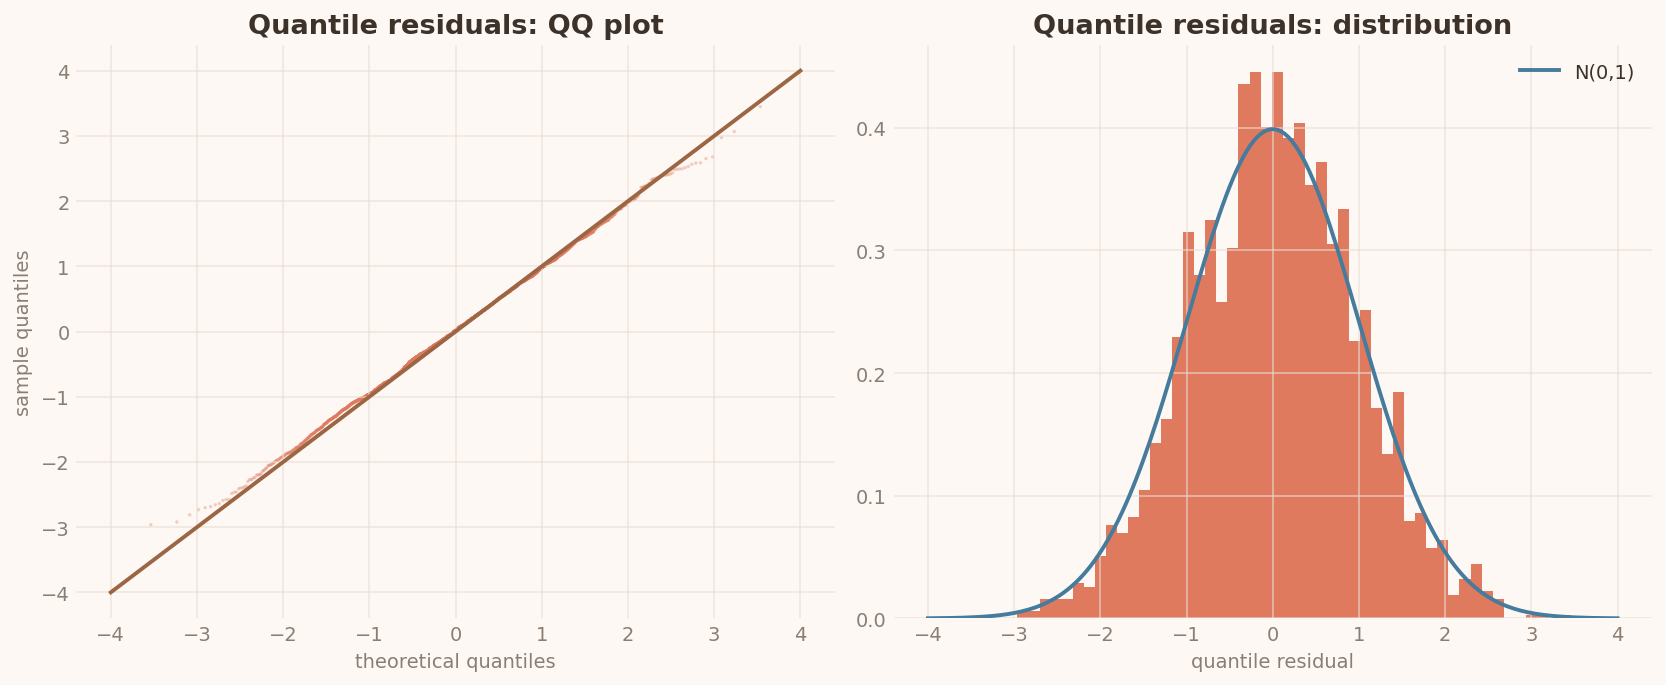

Mean = 0.018,  Std = 0.960  (expected: 0.000, 1.000)


In [6]:
phi = sev_fit.scale
shape_param = 1.0 / phi
mu_hat = severity_model.predict_mean(sev_fit, Xs_te)

u = gamma_dist.cdf(ys_te.values, a=shape_param, scale=mu_hat * phi)
u = np.clip(u, 1e-10, 1 - 1e-10)
qresid = norm.ppf(u)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# QQ plot
sorted_r = np.sort(qresid)
n = len(sorted_r)
theoretical = norm.ppf(np.linspace(0.5 / n, 1 - 0.5 / n, n))
axes[0].scatter(theoretical, sorted_r, s=3, alpha=0.35,
                color=style.PRIMARY, edgecolors="none")
axes[0].plot([-4, 4], [-4, 4], color=style.ACCENT, lw=2)
axes[0].set_xlabel("theoretical quantiles")
axes[0].set_ylabel("sample quantiles")
axes[0].set_title("Quantile residuals: QQ plot")

# Histogram vs N(0,1)
axes[1].hist(qresid, bins=50, color=style.PRIMARY,
             edgecolor="none", density=True)
xg = np.linspace(-4, 4, 200)
axes[1].plot(xg, norm.pdf(xg), color=style.SECONDARY, lw=2, label="N(0,1)")
axes[1].set_xlabel("quantile residual")
axes[1].set_title("Quantile residuals: distribution")
axes[1].legend()

fig.tight_layout(); plt.show()
print(f"Mean = {qresid.mean():.3f},  Std = {qresid.std():.3f}  "
      f"(expected: 0.000, 1.000)")

### 2.3 GBM Benchmark

Gradient-boosted trees fitted **separately** for frequency and severity
consistently outperform GLMs in discrimination while preserving the
product-form architecture (Henckaerts et al. 2021, NAAJ 25(2): 255–285).

- **Frequency**: `HistGradientBoostingClassifier` (log-loss)
- **Severity**: `HistGradientBoostingRegressor` (gamma deviance)

In [7]:
gbm_freq = HistGradientBoostingClassifier(
    max_iter=300, max_depth=4, learning_rate=0.05,
    min_samples_leaf=50, random_state=42,
)
gbm_freq.fit(X_tr, y_tr)

p_gbm_te = gbm_freq.predict_proba(X_te)[:, 1]
gbm_freq_metrics = {
    "AUC": roc_auc_score(y_te, p_gbm_te),
    "Brier": brier_score_loss(y_te, p_gbm_te),
    "Mean pred": p_gbm_te.mean(),
    "Observed": float(y_te.mean()),
}

gbm_sev = HistGradientBoostingRegressor(
    loss="gamma", max_iter=300, max_depth=4,
    learning_rate=0.05, min_samples_leaf=50, random_state=42,
)
gbm_sev.fit(Xs_tr, ys_tr)

mu_gbm_te = gbm_sev.predict(Xs_te)
gbm_sev_metrics = {
    "MAE (EUR)": mean_absolute_error(ys_te, mu_gbm_te),
    "Mean pred": mu_gbm_te.mean(),
    "Observed": float(ys_te.mean()),
    "Rank corr": spearmanr(ys_te, mu_gbm_te).statistic,
}

print("GBM Frequency:", {k: round(v, 4) for k, v in gbm_freq_metrics.items()})
print("GBM Severity: ", {k: round(v, 4) for k, v in gbm_sev_metrics.items()})

GBM Frequency: {'AUC': 0.7034, 'Brier': 0.2185, 'Mean pred': np.float64(0.4933), 'Observed': 0.4955}
GBM Severity:  {'MAE (EUR)': 626.0304, 'Mean pred': np.float64(836.6851), 'Observed': 861.3003, 'Rank corr': np.float64(0.2127)}


In [8]:
p_gbm_full  = gbm_freq.predict_proba(X_freq_full)[:, 1]
X_sev_aligned = X_freq_full.reindex(columns=sev_columns, fill_value=0)
mu_gbm_full = gbm_sev.predict(X_sev_aligned)

pp_gbm = pd.DataFrame({
    "p_claim": p_gbm_full,
    "exp_severity": mu_gbm_full,
    "pure_premium": p_gbm_full * mu_gbm_full,
})
print(f"GBM pure premium — mean: {pp_gbm['pure_premium'].mean():.1f} EUR, "
      f"median: {pp_gbm['pure_premium'].median():.1f} EUR")

GBM pure premium — mean: 411.7 EUR, median: 328.2 EUR


### 2.4 Model Comparison — GLM vs GBM

Discrimination power is measured by the **Gini coefficient**
($= 2 \times$ area between ordered Lorenz curve and the 45° line).
Higher Gini means the model concentrates predicted losses among genuinely
high-risk policies more effectively (Frees, Meyers & Cummings 2011, JASA).

In [9]:
def gini_from_lorenz(pp_df):
    pop, cum = pure_premium.lorenz_curve(pp_df)
    area = np.trapezoid(cum, pop)
    return 1 - 2 * area

gini_glm = gini_from_lorenz(pp_glm)
gini_gbm = gini_from_lorenz(pp_gbm)

comparison = pd.DataFrame({
    "GLM": {
        "Freq AUC": freq_metrics["auc"],
        "Freq Brier": freq_metrics["brier"],
        "Sev MAE (EUR)": sev_metrics["mae"],
        "Mean PP (EUR)": pp_glm["pure_premium"].mean(),
        "Gini index": gini_glm,
    },
    "GBM": {
        "Freq AUC": gbm_freq_metrics["AUC"],
        "Freq Brier": gbm_freq_metrics["Brier"],
        "Sev MAE (EUR)": gbm_sev_metrics["MAE (EUR)"],
        "Mean PP (EUR)": pp_gbm["pure_premium"].mean(),
        "Gini index": gini_gbm,
    },
}).round(4)
comparison

,GLM,GBM
Freq AUC,0.6894,0.7034
Freq Brier,0.2229,0.2185
Sev MAE (EUR),634.2401,626.0304
Mean PP (EUR),428.2949,411.7031
Gini index,0.2971,0.3257


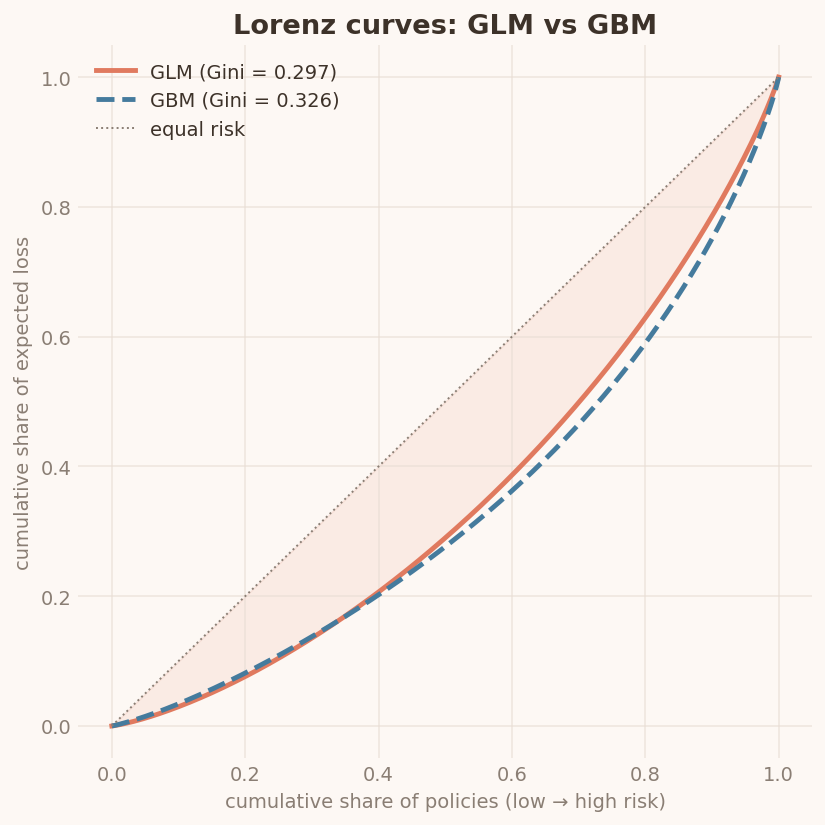

In [10]:
fig, ax = plt.subplots(figsize=(6, 6))
pop_glm, cum_glm = pure_premium.lorenz_curve(pp_glm)
pop_gbm, cum_gbm = pure_premium.lorenz_curve(pp_gbm)

ax.fill_between(pop_glm, cum_glm, pop_glm, alpha=0.10, color=style.PRIMARY)
ax.plot(pop_glm, cum_glm, lw=2.5, color=style.PRIMARY,
        label=f"GLM (Gini = {gini_glm:.3f})")
ax.plot(pop_gbm, cum_gbm, lw=2.5, color=style.SECONDARY, linestyle="--",
        label=f"GBM (Gini = {gini_gbm:.3f})")
ax.plot([0, 1], [0, 1], ":", color=style.TEXT_MUTED, lw=1, label="equal risk")
ax.set_xlabel("cumulative share of policies (low → high risk)")
ax.set_ylabel("cumulative share of expected loss")
ax.set_title("Lorenz curves: GLM vs GBM")
ax.legend()
fig.tight_layout(); plt.show()

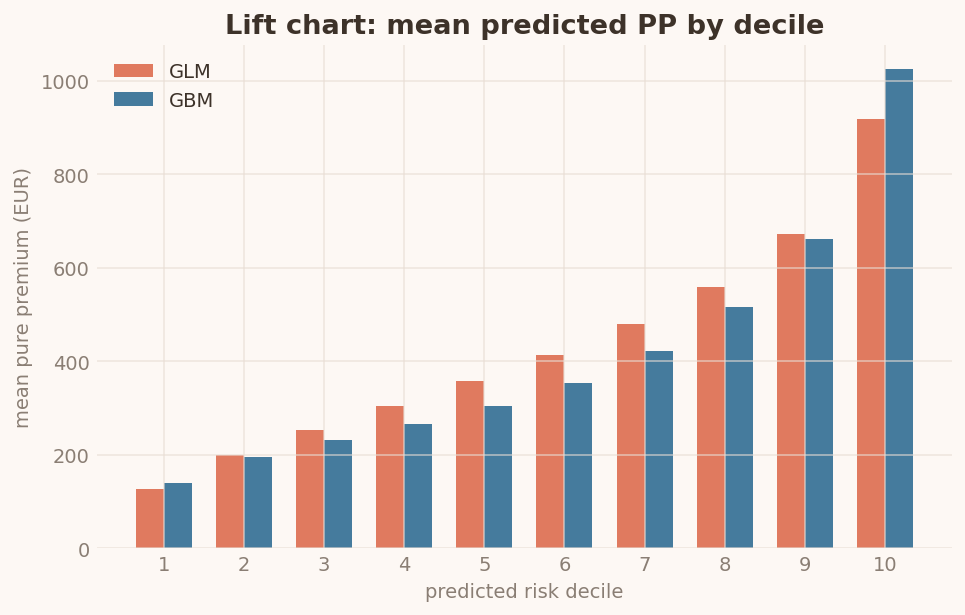

In [11]:
def decile_means(pp_series, n=10):
    d = pd.qcut(pp_series, n, labels=False, duplicates="drop") + 1
    return pp_series.groupby(d).mean()

lift_glm = decile_means(pp_glm["pure_premium"])
lift_gbm = decile_means(pp_gbm["pure_premium"])

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(1, len(lift_glm) + 1)
w = 0.35
ax.bar(x - w / 2, lift_glm.values, w, label="GLM",
       color=style.PRIMARY, edgecolor="none")
ax.bar(x + w / 2, lift_gbm.values, w, label="GBM",
       color=style.SECONDARY, edgecolor="none")
ax.set_xlabel("predicted risk decile")
ax.set_ylabel("mean pure premium (EUR)")
ax.set_title("Lift chart: mean predicted PP by decile")
ax.set_xticks(x)
ax.legend()
fig.tight_layout(); plt.show()

---
## 3. Customer Profiling

We translate model scores into actionable customer segments via loss-factor
analysis, interpretable tree rules, and management-ready profile cards.

### 3.1 Loss-Factor Decile Analysis

The **loss factor** $\text{LF}_i = \hat\pi_i\, /\, \overline{\hat\pi}$
benchmarks each policy against the portfolio average — the standard
profitability proxy when premium data is absent
(Werner & Modlin 2016, Ch. 8; Goldburd et al. 2020 §7).

In [12]:
pp_all = pp_glm.copy()
pp_all["loss_factor"] = pp_all["pure_premium"] / pp_all["pure_premium"].mean()
pp_all["decile"] = pd.qcut(
    pp_all["pure_premium"], 10, labels=False, duplicates="drop",
) + 1

decile_tbl = pp_all.groupby("decile").agg(
    n=("pure_premium", "size"),
    mean_pp=("pure_premium", "mean"),
    median_pp=("pure_premium", "median"),
    mean_LF=("loss_factor", "mean"),
    total_pp=("pure_premium", "sum"),
).round(2)
decile_tbl["pct_loss"] = (
    decile_tbl["total_pp"] / decile_tbl["total_pp"].sum() * 100
).round(1)
decile_tbl["cum_pct_loss"] = decile_tbl["pct_loss"].cumsum().round(1)
decile_tbl

,n,mean_pp,median_pp,mean_LF,total_pp,pct_loss,cum_pct_loss
decile,,,,,,,
1,2478,127.10,131.47,0.30,314946.80,3.0,3.0
2,2477,199.07,199.56,0.46,493104.89,4.6,7.6
3,2477,253.70,254.23,0.59,628419.77,5.9,13.5
4,2478,304.53,304.78,0.71,754623.16,7.1,20.6
5,2477,357.17,356.77,0.83,884714.90,8.3,28.9
6,2477,413.69,413.30,0.97,1024708.15,9.7,38.6
7,2478,478.90,478.34,1.12,1186718.81,11.2,49.8
8,2477,559.41,558.10,1.31,1385646.30,13.1,62.9
9,2477,671.89,667.84,1.57,1664272.22,15.7,78.6


In [13]:
top10_share = decile_tbl.loc[10, "pct_loss"]
top20_share = decile_tbl.loc[[9, 10], "pct_loss"].sum()
top10_lf    = decile_tbl.loc[10, "mean_LF"]
bot50_share = decile_tbl.loc[1:5, "pct_loss"].sum()

print("=" * 55)
print("  EXECUTIVE SUMMARY — LOSS CONCENTRATION")
print("=" * 55)
print(f"  Top 10% of policies:    {top10_share:.1f}% of expected losses  "
      f"(LF = {top10_lf:.2f}x)")
print(f"  Top 20% of policies:    {top20_share:.1f}% of expected losses")
print(f"  Bottom 50% of policies: {bot50_share:.1f}% of expected losses")
print("=" * 55)

  EXECUTIVE SUMMARY — LOSS CONCENTRATION
  Top 10% of policies:    21.4% of expected losses  (LF = 2.14x)
  Top 20% of policies:    37.1% of expected losses
  Bottom 50% of policies: 28.9% of expected losses


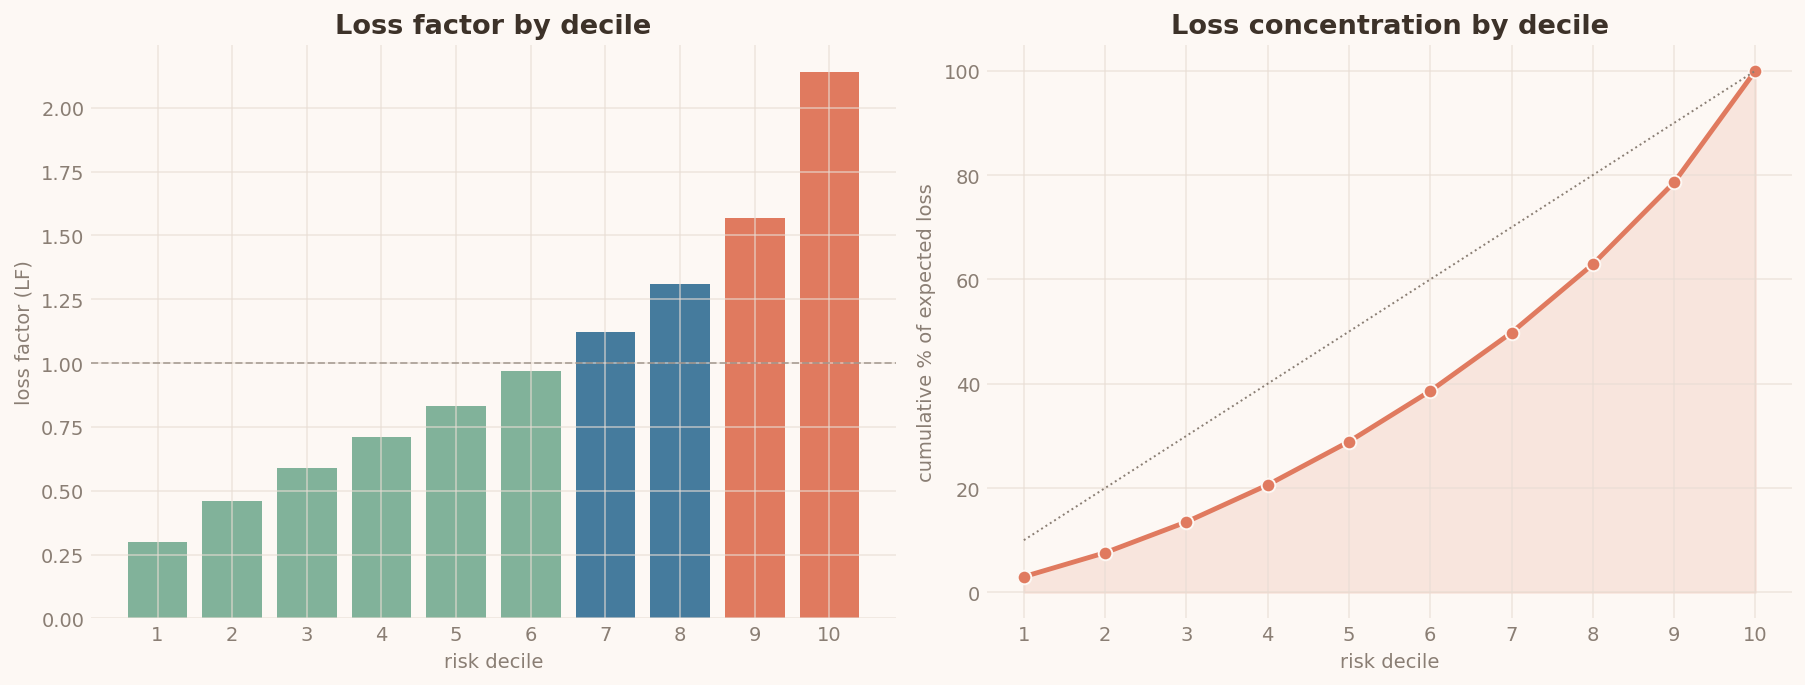

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = [style.PALETTE[0] if lf > 1.5 else style.PALETTE[3]
          if lf > 1.0 else style.PALETTE[1]
          for lf in decile_tbl["mean_LF"]]
ax.bar(decile_tbl.index, decile_tbl["mean_LF"],
       color=colors, edgecolor="none")
ax.axhline(1.0, color=style.TEXT_MUTED, linestyle="--", lw=1, alpha=0.6)
ax.set_xlabel("risk decile")
ax.set_ylabel("loss factor (LF)")
ax.set_title("Loss factor by decile")
ax.set_xticks(decile_tbl.index)

ax = axes[1]
ax.fill_between(decile_tbl.index, decile_tbl["cum_pct_loss"],
                alpha=0.15, color=style.PRIMARY)
ax.plot(decile_tbl.index, decile_tbl["cum_pct_loss"], marker="o", lw=2.5,
        color=style.PRIMARY, markeredgecolor=style.BG, markersize=7)
ax.plot(decile_tbl.index, np.linspace(10, 100, 10), ":",
        color=style.TEXT_MUTED, lw=1)
ax.set_xlabel("risk decile")
ax.set_ylabel("cumulative % of expected loss")
ax.set_title("Loss concentration by decile")
ax.set_xticks(decile_tbl.index)

fig.tight_layout(); plt.show()

### 3.2 Surrogate-Tree Segmentation

A shallow decision tree fitted on $\hat\pi$ as the response extracts
**interpretable IF-THEN rules** that bridge the gap between the statistical
model and management communication (Henckaerts et al. 2021 §4).

In [15]:
tree_X = freq_df[["age", "density", "nYears", "carVal"]].copy()
for col in ["gender", "carType", "carCat", "job", "cover"]:
    tree_X[col] = freq_df[col].cat.codes

surrogate = DecisionTreeRegressor(
    max_depth=4, min_samples_leaf=200, random_state=42,
)
surrogate.fit(tree_X, pp_all["pure_premium"])

print(f"Surrogate tree R² = {surrogate.score(tree_X, pp_all['pure_premium']):.3f}")
print()
print(export_text(surrogate, feature_names=list(tree_X.columns), max_depth=3))

Surrogate tree R² = 0.784

|--- age <= 33.50
|   |--- density <= 148.78
|   |   |--- job <= 3.50
|   |   |   |--- age <= 25.50
|   |   |   |   |--- value: [497.58]
|   |   |   |--- age >  25.50
|   |   |   |   |--- value: [387.70]
|   |   |--- job >  3.50
|   |   |   |--- gender <= 0.50
|   |   |   |   |--- value: [523.34]
|   |   |   |--- gender >  0.50
|   |   |   |   |--- value: [676.38]
|   |--- density >  148.78
|   |   |--- job <= 3.50
|   |   |   |--- density <= 211.01
|   |   |   |   |--- value: [614.62]
|   |   |   |--- density >  211.01
|   |   |   |   |--- value: [768.71]
|   |   |--- job >  3.50
|   |   |   |--- density <= 236.91
|   |   |   |   |--- value: [884.59]
|   |   |   |--- density >  236.91
|   |   |   |   |--- value: [1089.34]
|--- age >  33.50
|   |--- density <= 168.29
|   |   |--- age <= 48.50
|   |   |   |--- job <= 3.50
|   |   |   |   |--- value: [282.46]
|   |   |   |--- job >  3.50
|   |   |   |   |--- value: [405.80]
|   |   |--- age >  48.50
|   |   |  

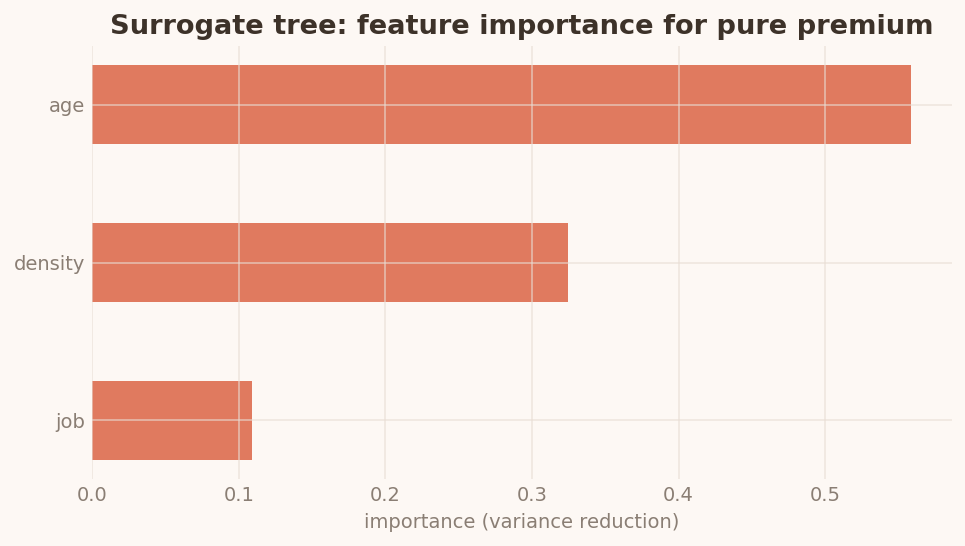

In [16]:
importances = pd.Series(
    surrogate.feature_importances_, index=tree_X.columns,
).sort_values(ascending=True)
importances = importances[importances > 0.01]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(importances.index, importances.values,
        color=style.PRIMARY, edgecolor="none", height=0.5)
ax.set_xlabel("importance (variance reduction)")
ax.set_title("Surrogate tree: feature importance for pure premium")
fig.tight_layout(); plt.show()

### 3.3 Risk Tiers & Action Matrix

Following the practitioner framework in Goldburd et al. (2020, CAS
Monograph 5, §7–8) and Werner & Modlin (2016, Ch. 11), each tier is
mapped to a concrete management action based on its loss factor.

In [17]:
tiers = profiling.assign_tiers(pp_glm)
tier_tbl = profiling.tier_summary(freq_df, pp_glm, tiers)

portfolio_mean = pp_glm["pure_premium"].mean()
tier_tbl["loss_factor"] = (tier_tbl["mean_pp"] / portfolio_mean).round(2)

tier_tbl[["n", "mean_pp", "loss_factor", "pct_of_portfolio",
          "pct_of_total_loss"]].round(2)

,n,mean_pp,loss_factor,pct_of_portfolio,pct_of_total_loss
tier,,,,,
Low,12387,248.31,0.58,50.0,28.99
Medium,7432,484.00,1.13,30.0,33.90
High,3716,716.48,1.67,15.0,25.09
Very High,1239,1029.25,2.40,5.0,12.02


In [18]:
action_map = {
    "Low":       ("< 0.7",     "Retain; cross-sell opportunities"),
    "Medium":    ("0.7 – 1.3", "Standard renewal; monitor trends"),
    "High":      ("1.3 – 2.0", "Re-price (+15–25%); raise deductible"),
    "Very High": ("> 2.0",     "Coverage restriction or non-renewal referral"),
}

rows = []
for t in tier_tbl.index:
    lf_range, action = action_map[t]
    rows.append({
        "Tier": t,
        "Policies": int(tier_tbl.loc[t, "n"]),
        "Mean PP": f"{tier_tbl.loc[t, 'mean_pp']:.0f} EUR",
        "Loss Factor": tier_tbl.loc[t, "loss_factor"],
        "% Portfolio": tier_tbl.loc[t, "pct_of_portfolio"],
        "% Loss": round(tier_tbl.loc[t, "pct_of_total_loss"], 1),
        "LF Range": lf_range,
        "Recommended Action": action,
    })
pd.DataFrame(rows).set_index("Tier")

,Policies,Mean PP,Loss Factor,% Portfolio,% Loss,LF Range,Recommended Action
Tier,,,,,,,
Low,12387,248 EUR,0.58,50.000000,29.0,< 0.7,Retain; cross-sell opportunities
Medium,7432,484 EUR,1.13,29.999193,33.9,0.7 – 1.3,Standard renewal; monitor trends
High,3716,716 EUR,1.67,14.999596,25.1,1.3 – 2.0,Re-price (+15–25%); raise deductible
Very High,1239,1029 EUR,2.40,5.001211,12.0,> 2.0,Coverage restriction or non-renewal referral


### 3.4 Profile Cards — Unprofitable Segments

One-page demographic summaries for the two highest-risk tiers.
These humanize the segments for stakeholder discussion.

In [19]:
for label in ["Very High", "High"]:
    prof = profiling.describe_top_segment(
        freq_df, pp_glm, tiers, segment_label=label,
    )
    pct_loss = tier_tbl.loc[label, "pct_of_total_loss"]
    action   = action_map[label][1]

    print("=" * 60)
    print(f"  PROFILE CARD: {label} Risk Tier")
    print("=" * 60)
    print(f"  Policies:          {prof['n_policies']:,} "
          f"({prof['share_of_portfolio_pct']}% of book)")
    print(f"  Mean pure premium: {prof['mean_pure_premium']:,.0f} EUR")
    print(f"  Loss factor:       "
          f"{prof['ratio_to_overall_mean']:.1f}x portfolio mean")
    print(f"  Share of loss:     {pct_loss:.1f}%")
    print("-" * 60)
    print("  Typical profile:")
    for k, v in prof["typical_profile"].items():
        print(f"    {k:>12s}: {v}")
    print("-" * 60)
    print(f"  Action: {action}")
    print("=" * 60)
    print()

  PROFILE CARD: Very High Risk Tier
  Policies:          1,239 (5.0% of book)
  Mean pure premium: 1,029 EUR
  Loss factor:       2.4x portfolio mean
  Share of loss:     12.0%
------------------------------------------------------------
  Typical profile:
          uwYear: 2010 (61%)
          gender: Male (86%)
         carType: A (36%)
          carCat: Small (43%)
             job: Unemployed (62%)
           cover: 0 (86%)
             age: 23.3
          nYears: 4.0
          carVal: 17974.2
         density: 236.9
------------------------------------------------------------
  Action: Coverage restriction or non-renewal referral

  PROFILE CARD: High Risk Tier
  Policies:          3,716 (15.0% of book)
  Mean pure premium: 716 EUR
  Loss factor:       1.7x portfolio mean
  Share of loss:     25.1%
------------------------------------------------------------
  Typical profile:
          uwYear: 2010 (55%)
          gender: Male (77%)
         carType: A (28%)
          carCat: Sma

---
## 4. Validation & Conclusions

### 4.1 Bootstrap Uncertainty Quantification

We resample both datasets ($B = 200$), refit both GLMs on each replicate,
recompute $\hat\pi$ and the tier-level loss factor. The resulting 95 %
confidence intervals quantify **estimation uncertainty** — how much the LF
would shift with a different sample from the same population.

In [20]:
rng = np.random.default_rng(42)
B = 200
tier_labels = ["Low", "Medium", "High", "Very High"]
boot_lf = {t: [] for t in tier_labels}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for b in range(B):
        if (b + 1) % 50 == 0:
            print(f"  bootstrap {b + 1}/{B}")
        try:
            idx_f = rng.choice(len(freq_df), len(freq_df), replace=True)
            idx_s = rng.choice(len(sev_df), len(sev_df), replace=True)

            Xf_b = preprocessing.build_design_matrix(freq_df.iloc[idx_f])
            yf_b = freq_df.iloc[idx_f][FREQ_TARGET]
            fit_f = frequency_model.fit_logit(Xf_b, yf_b)

            Xs_b = preprocessing.build_design_matrix(sev_df.iloc[idx_s])
            ys_b = sev_df.iloc[idx_s][SEV_TARGET]
            fit_s = severity_model.fit_gamma_glm(Xs_b, ys_b)

            pp_b = pure_premium.compute_pure_premium(
                X_freq_full, fit_f, fit_s, sev_columns=sev_columns,
            )
            tiers_b = profiling.assign_tiers(pp_b)
            mean_b  = pp_b["pure_premium"].mean()
            for t in tier_labels:
                mask = tiers_b == t
                if mask.sum() > 0:
                    boot_lf[t].append(
                        pp_b.loc[mask, "pure_premium"].mean() / mean_b
                    )
        except Exception:
            continue

print(f"Completed {len(boot_lf['Low'])} / {B} successful replications")

  bootstrap 50/200


  bootstrap 100/200


  bootstrap 150/200


  bootstrap 200/200
Completed 200 / 200 successful replications


In [21]:
ci_rows = []
for t in tier_labels:
    v = np.array(boot_lf[t])
    ci_rows.append({
        "Tier": t,
        "Mean LF": round(v.mean(), 3),
        "Std": round(v.std(), 3),
        "CI 2.5%": round(np.percentile(v, 2.5), 3),
        "CI 97.5%": round(np.percentile(v, 97.5), 3),
    })

ci_df = pd.DataFrame(ci_rows).set_index("Tier")
ci_df

,Mean LF,Std,CI 2.5%,CI 97.5%
Tier,,,,
Low,0.580,0.009,0.564,0.596
Medium,1.128,0.004,1.121,1.136
High,1.673,0.015,1.643,1.701
Very High,2.412,0.043,2.326,2.495


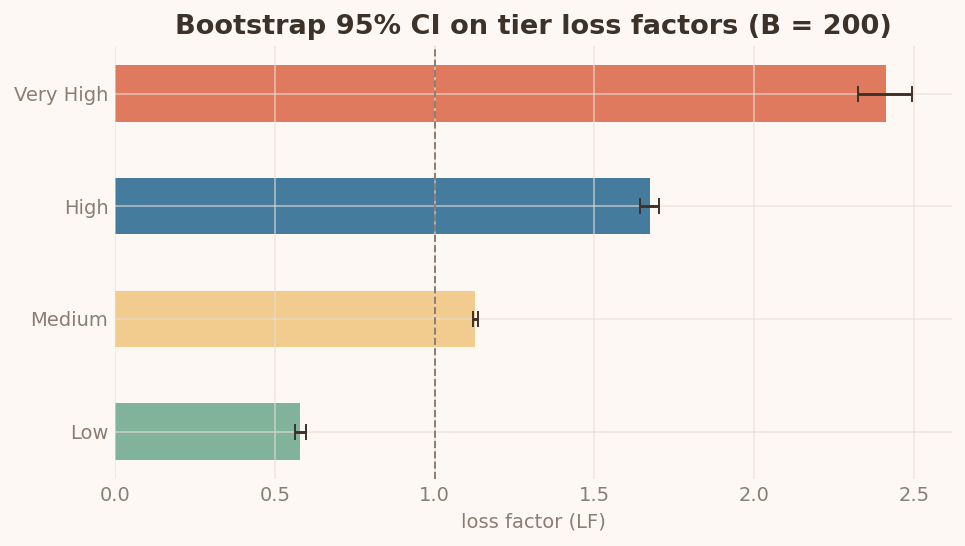

In [22]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(tier_labels))
means = ci_df["Mean LF"].values
lo = means - ci_df["CI 2.5%"].values
hi = ci_df["CI 97.5%"].values - means

bar_colors = [style.PALETTE[1], style.PALETTE[2],
              style.PALETTE[3], style.PALETTE[0]]
ax.barh(x, means, color=bar_colors, edgecolor="none", height=0.5)
ax.errorbar(means, x, xerr=[lo, hi], fmt="none",
            ecolor=style.TEXT, capsize=4, lw=1.5)
ax.axvline(1.0, color=style.TEXT_MUTED, linestyle="--", lw=1)
ax.set_yticks(x)
ax.set_yticklabels(tier_labels)
ax.set_xlabel("loss factor (LF)")
ax.set_title("Bootstrap 95% CI on tier loss factors (B = 200)")
fig.tight_layout(); plt.show()

---
### 4.2 Key Findings & Caveats

### Headline results

1. **GLM and GBM agree** on the overall risk ranking — the portfolio
   concentration structure is robust to model choice.
2. **The top decile** carries a disproportionate share of expected losses
   at a loss factor well above 2x — candidates for immediate premium action.
3. **The unprofitable profile is coherent and actionable**: young (~23 y),
   male (~86%), unemployed (~62%), urban (~237 inh/km²), without
   material-damage cover (~86%).
4. **Bootstrap CIs** confirm that tier-level loss factors are estimated
   with reasonable precision — the ranking is stable, not a sampling artefact.

### Honest caveats (Garrido et al. 2016; Werner & Modlin 2016)

- **No premium data** → profitability is portfolio-relative, not absolute.
  If the portfolio itself is unprofitable, below-mean customers may still
  lose money.
- **Independence assumption** ($N \perp Y \mid \mathbf{x}$) is invoked, not
  tested — without record-linkage, dependent-frequency-severity models are
  inapplicable. Mean-prediction bias is typically modest; tail/variance bias
  can be larger.
- **~12 k severity records** limit severity-side complexity; rare-cell
  instability in interactions should be watched.
- Bootstrap CIs quantify estimation uncertainty, not model-specification
  uncertainty.

### Methodology note

> *"The standard GLM tariff analysis is to do separate analyses for claim
> frequency and claim severity, and then relativities for the pure premium
> are found by multiplying the results."*
> — Ohlsson & Johansson (2010)

The two-stage marginal decomposition is **not a workaround** — it is the
canonical pricing pipeline. The GBM benchmark confirms robustness. The
deliverable — relative ranking of customer profiles by expected loss for
renewal action — is exactly what this architecture is designed to produce.